In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd

data = {
    "Word_Frequency":[2,3,5,8,1,9,7,2,10,6,3,8,1,9,5],
    "Message_Length":[50,60,120,180,45,200,160,55,220,150,70,190,40,210,130],
    "Spam":[0,0,0,1,0,1,1,0,1,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

print(df)

    Word_Frequency  Message_Length  Spam
0                2              50     0
1                3              60     0
2                5             120     0
3                8             180     1
4                1              45     0
5                9             200     1
6                7             160     1
7                2              55     0
8               10             220     1
9                6             150     1
10               3              70     0
11               8             190     1
12               1              40     0
13               9             210     1
14               5             130     0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

X = df[['Word_Frequency','Message_Length']]
y = df['Spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

classifier = SVC(kernel='linear')

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666

Confusion Matrix
[[1 0]
 [1 1]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



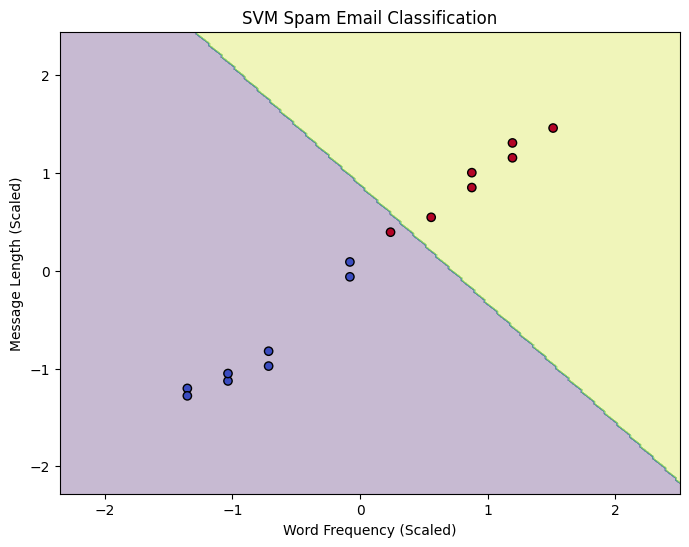

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X_vis = scaler.transform(X)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y, cmap='coolwarm', edgecolors='k')

plt.title("SVM Spam Email Classification")
plt.xlabel("Word Frequency (Scaled)")
plt.ylabel("Message Length (Scaled)")
plt.show()